## RED NEURONAL RESNET 18

En este notebook implementaremos una **Red Neuronal ResNet 18 (CNN)**. Esta arquitectura aprovecha la jerarquía espacial de las imágenes de Fashion-MNIST mediante una capa convolucional y la operación *Global Average Pooling (GAP).*

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from tensorflow.keras.datasets import fashion_mnist
from keras.optimizers import Adam
import random



# 1. Carga de datos
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# 2. Preprocesamiento: Normalización y Reshape para CNN (28, 28, 1)
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train_full = X_train_full.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# 3. División de datos (Entrenamiento, Validación, Test)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full,
                                      test_size=0.2, random_state=42,
                                      stratify=y_train_full)

print(f"X (Train): {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X (Train): (48000, 28, 28, 1), X_val: (12000, 28, 28, 1), X_test: (10000, 28, 28, 1)


##2. Definición del Modelo CNN

Diseñaremos una arquitectura basada en Redes Neuronales ResNet 18les (CNN) siguiendo el principio de mínima complejidad. La convolución utiliza filtros locales que permiten capturar patrones espaciales y texturas, elementos clave en imágenes de prendas de ropa.

La arquitectura propuesta es un ejercicio de eficiencia extrema que utiliza:

1. **Capa ResNet 18l:** Con kernels de $3 \times 3$ para extraer rasgos característicos (bordes, uniones, tramas).
2. **Activación ReLU:** Para introducir la no linealidad necesaria que permite distinguir formas complejas.
3. **Global Average Pooling (GAP):** En lugar de aplanar la imagen y usar capas densas (que dispararían el número de parámetros), el GAP reduce cada mapa de características a su promedio, conectando directamente con la salida.



In [2]:
import sys
from pathlib import Path


PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f"Raíz del proyecto añadida: {PROJECT_ROOT}")


Raíz del proyecto añadida: d:\Uni\Aprendizaje profundo\ProyectoAP


## 3. Entrenamiento

Entrenamos el modelo y visualizamos las curvas de aprendizaje.

## CNN con atencion

In [3]:
# 1. Importación correcta (asegúrate de que esta celda se ejecute)
from models.ResNet18 import create_resnet18, get_focal_loss
from keras.optimizers import Adam
import tensorflow as tf

# 2. Configuración y Entrenamiento
model = create_resnet18(l2=1e-4, dropout=0.3)

model.compile(
    #optimizer=Adam(learning_rate=0.01),
    optimizer='adam',
    loss=get_focal_loss(gamma=1.5, alpha=0.5),
    metrics=['accuracy']
)

class_weights = {
    0: 1.3,
    1: 1.0,
    2: 1.1,
    3: 1.0,
    4: 1.1,
    5: 1.0,
    6: 1.8,
    7: 1.0,
    8: 1.0,
    9: 1.0
}



# Definir Callbacks
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
]

# Entrenar (Recuerden que x_train_3c tiene 3 canales ahora)
history = model.fit(
    #x_train_3c, y,
    X_train, y_train,
    epochs=50,
    batch_size=1024,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/50
47/47 [==============================] - 8s 145ms/step - loss: 0.5738 - accuracy: 0.7262 - val_loss: 1.3038 - val_accuracy: 0.1661 - lr: 0.0010
Epoch 2/50
47/47 [==============================] - 7s 140ms/step - loss: 0.3688 - accuracy: 0.8695 - val_loss: 1.6802 - val_accuracy: 0.0932 - lr: 0.0010
Epoch 3/50
47/47 [==============================] - 7s 147ms/step - loss: 0.3178 - accuracy: 0.9005 - val_loss: 1.5521 - val_accuracy: 0.1450 - lr: 0.0010
Epoch 4/50
47/47 [==============================] - ETA: 0s - loss: 0.2863 - accuracy: 0.9155
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
47/47 [==============================] - 7s 141ms/step - loss: 0.2863 - accuracy: 0.9155 - val_loss: 2.0284 - val_accuracy: 0.1491 - lr: 0.0010
Epoch 5/50
47/47 [==============================] - 7s 142ms/step - loss: 0.2499 - accuracy: 0.9366 - val_loss: 1.6455 - val_accuracy: 0.1280 - lr: 5.0000e-04
Epoch 6/50
47/47 [==============================] - 7s 141ms/s

## 4. Matriz de Confusión

Visualizamos dónde se confunde el modelo utilizando el conjunto de test.

313/313 [==============================] - 1s 2ms/step


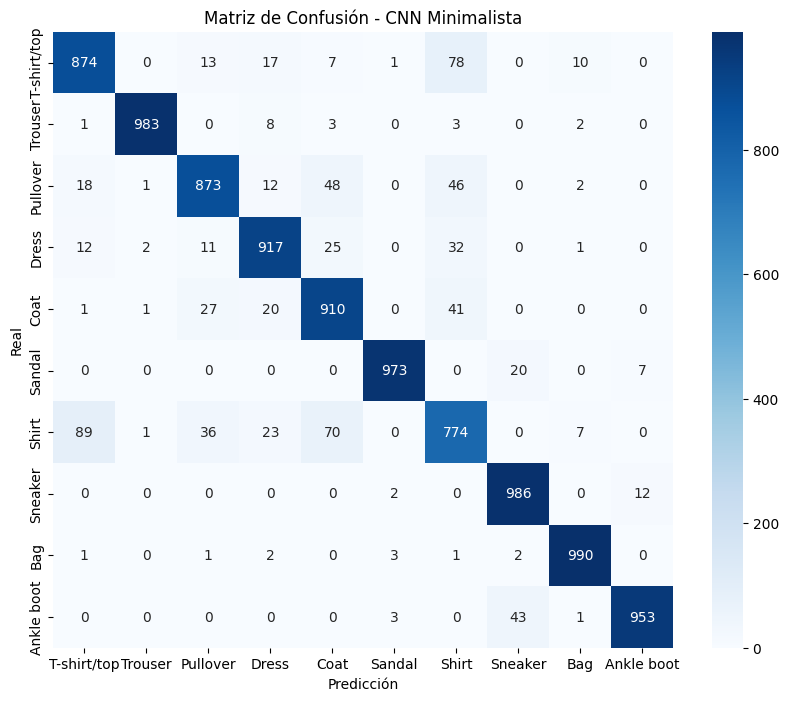

In [4]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

#y_pred = np.argmax(model.predict(x_test_3c), axis=1)
#cm = confusion_matrix(y_test, y_pred)

y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - CNN Minimalista')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

313/313 [==============================] - 1s 3ms/step


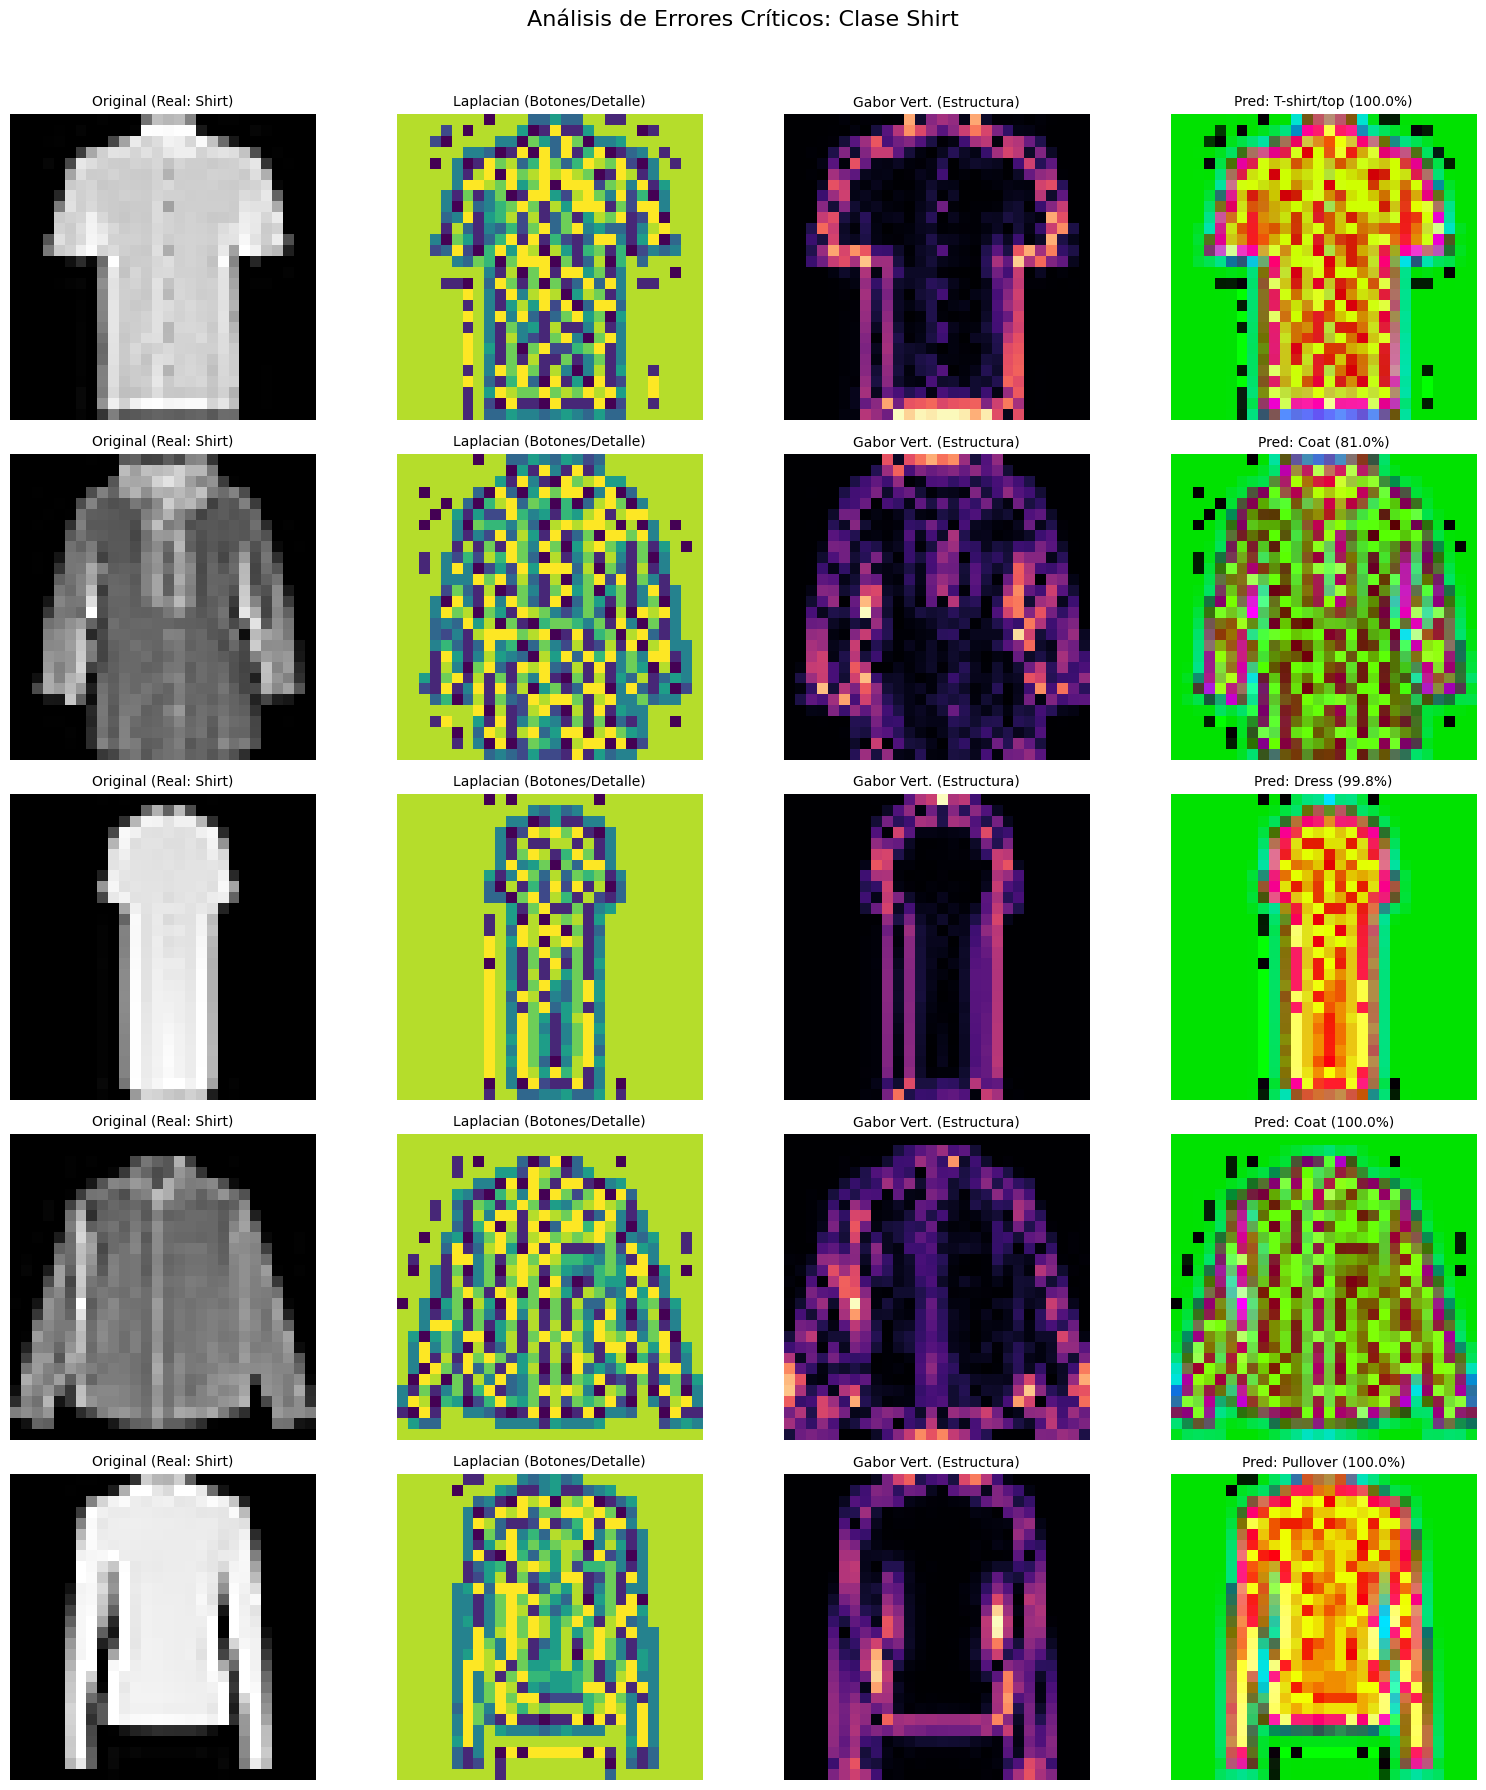

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def visualizar_errores_optimizados(model, x_3c, y_real, class_names, target_class=6, num_images=5):
    # Predicciones del modelo
    preds = model.predict(x_3c)
    pred_labels = np.argmax(preds, axis=1)
    
    # Encontrar índices donde la realidad es la clase objetivo (ej. Shirt) pero el modelo falló
    error_indices = np.where((y_real == target_class) & (pred_labels != target_class))[0]
    
    if len(error_indices) == 0:
        print(f"✅ ¡Increíble! No hay errores para la clase {class_names[target_class]}")
        return

    plt.figure(figsize=(16, num_images * 3.5))
    
    for i, idx in enumerate(error_indices[:num_images]):
        img_3c = x_3c[idx]
        actual = class_names[y_real[idx]]
        predicha = class_names[pred_labels[idx]]
        confianza = preds[idx][pred_labels[idx]] * 100
        
        # Definir los canales actualizados
        # Canal 0: Original
        # Canal 1: Laplacian (Costuras/Botones)
        # Canal 2: Gabor Vertical (Estructura central)
        
        imgs = [img_3c[:, :, 0], img_3c[:, :, 1], img_3c[:, :, 2], img_3c]
        titles = [
            f'Original (Real: {actual})', 
            'Laplacian (Botones/Detalle)', 
            f'Gabor Vert. (Estructura)',
            f'Pred: {predicha} ({confianza:.1f}%)'
        ]
        cmaps = ['gray', 'viridis', 'magma', None] # Mapas de color optimizados para cada característica
        
        for j in range(4):
            plt.subplot(num_images, 4, i * 4 + j + 1)
            plt.imshow(imgs[j], cmap=cmaps[j])
            plt.title(titles[j], fontsize=10)
            plt.axis('off')
            
    plt.suptitle(f'Análisis de Errores Críticos: Clase {class_names[target_class]}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Ejecutar el análisis para la clase 'Shirt' (6)
visualizar_errores_optimizados(model, x_test_3c, y_test, class_names, target_class=6)


In [ ]:
def plot_error_analysis_v2(indices, x_data, y_true, y_pred, class_names):
    n_samples = len(indices)
    fig, axes = plt.subplots(n_samples, 4, figsize=(15, 3 * n_samples))
    for i, idx in enumerate(indices):
        img_3c = x_data[idx]
        # Canal 0
        axes[i, 0].imshow(img_3c[:,:,0], cmap='gray')
        axes[i, 0].set_title(f"Real: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}")
        # Canal 1
        axes[i, 1].imshow(img_3c[:,:,1], cmap='viridis')
        axes[i, 1].set_title("Laplacian (Botones)")
        # Canal 2
        axes[i, 2].imshow(img_3c[:,:,2], cmap='magma')
        axes[i, 2].set_title("Gabor Vert. (Estructura)")
        # RGB
        axes[i, 3].imshow(img_3c)
        axes[i, 3].set_title("Combinación CNN")
    plt.tight_layout()
    plt.show()

# Ejecutar con los nuevos índices de error
y_pred = np.argmax(model.predict(x_test_3c), axis=1)
idx_err = np.where((y_test == 0) & (y_pred == 6))[0][:3] # T-shirt como Shirt
plot_error_analysis_v2(idx_err, x_test_3c, y_test, y_pred, class_names)


## 5. Evaluación Final

In [ ]:
# Curvas de Aprendizaje
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Convergencia (Loss)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Precisión (Accuracy)')
plt.legend()
plt.show()

# Evaluación en Test
y_pred = np.argmax(model.predict(X_test), axis=1)
test_acc = accuracy_score(y_test, y_pred)
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"\n--- RESULTADOS FINALES ---")
print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")
print(f"Parámetros: {model.count_params()}")

## Resumen de Resultados - CNN

| Modelo | Parámetros |Train Acc | Val Acc | Test Acc
| :--- | :---: | :---: | :---: |:---
| **CNN** | 1,726 | 0.8490 | 0.8454 | 0.8395

### Análisis del Modelo CNN

Hemos construido una Red CNN sencilla con solo 2 capas convulucionales y global_average_pooling2d.

Al principio había bastante cuello de botella ya que la red obtenía mejores resultados en validación en la primeras épocas, después ya se estabilizaba.
Al ajustar el learning rate a 0.01 y el orden correcto del los filtros en las capas convulucionales, vemos una mejora significativa.

Se observa que el modelo no es tan preciso con clases que son muy similares.
Nuestro principal reto será conseguir que el modelo clasifique bien las clases muy similares como Camisas y Abrigos.

Podremos añadir más capas al modelo y/o probar funciones de perdida ajustadas para penalizar más los errores en las clases muy similares.
